# Preamble

Install packages

In [ ]:
!pip install DSGRN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.3/223.3 kB 10.3 MB/s eta 0:00:00


In [ ]:
!pip install --no-deps git+https://github.com/marciogameiro/DSGRN_utils.git

  Cloning https://github.com/marciogameiro/DSGRN_utils.git to /tmp/pip-req-build-k4re3ioi
  Running command git clone --filter=blob:none --quiet https://github.com/marciogameiro/DSGRN_utils.git /tmp/pip-req-build-k4re3ioi
  Resolved https://github.com/marciogameiro/DSGRN_utils.git to commit 023a3461e595e5a70917e9ba1fafca7e1b5dff30
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for DSGRN_utils: filename=dsgrn_utils-1.0.0-py3-none-any.whl size=31094 sha256=2b457bd4444e137741205d0aece862b0b64c77993cf28a2b9e63c77d07d98b0f
  Stored in directory: /tmp/pip-ephem-wheel-cache-ndv60hdx/wheels/00/fa/a0/57556b77083fc89302a7f7f3b85c1f4b3216eed0abc2e5ae29
Successfully built DSGRN_utils


Import packages

In [ ]:
import DSGRN
import DSGRN_utils
import json
import numpy as np
import warnings
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from typing import Tuple, Callable
from numpy.typing import ArrayLike, NDArray
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

Choose your model

In [ ]:
class HillFunction:

    def __init__(self, L: float, U: float, theta: float, d: float) -> None:
        if theta <= 0 or d <= 0:
            raise ValueError("θ and d must be positive")

        self.L = float(L)
        self.U = float(U)
        self.theta = float(theta)
        self.d = float(d)

    def _compute_ratio(self, x: ArrayLike) -> NDArray:
        ratio = np.zeros_like(x, dtype=float)
        positive = x > 0

        if np.any(positive):
            log_ratio = self.d * np.log(np.where(positive, x/self.theta, 1.0))
            ratio[positive] = np.exp(np.clip(log_ratio[positive], -700, 700))

        return ratio

    def __call__(self, x: ArrayLike) -> NDArray:

        x = np.asarray(x)
        ratio = self._compute_ratio(x)

        return self.L + np.where(np.isinf(ratio),
                                self.U - self.L,
                                (self.U - self.L) * ratio / (1 + ratio))

# Example 1: Toggle Switch

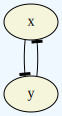

Number of parameter nodes: 9


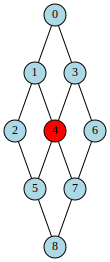

In [ ]:

net_spec = """x : (~y)
              y : (~x) """


network = DSGRN.Network(net_spec)
display(DSGRN.DrawGraph(network))



parameter_graph = DSGRN.ParameterGraph(network)
print('Number of parameter nodes:', parameter_graph.size())
display(DSGRN.draw_parameter_graph(parameter_graph))


sampler = DSGRN.ParameterSampler(network)

In [ ]:

par_index = 4
parameter = parameter_graph.parameter(par_index)


In [ ]:

L = np.array([[0.0, 0.8730297],
              [0.08856226, 0.0]])
U = np.array([[0.0, 1.47876582],
              [0.40910071, 0.0]])
T = np.array([[0.0, 0.22193859],
              [1.13937294, 0.0]])

D = np.zeros([network.size(), network.size()])
D[0,1] = 10
D[1,0] = 10

In [ ]:

def ode_function_1(t, x, *params):











  L, U, T, D = params


  hill01 = HillFunction(U[0,1], L[0,1], T[0,1],D[0,1])
  hill10 = HillFunction(U[1,0], L[1,0], T[1,0],D[1,0])


  x0, x1 = x


  dx0dt = -x0 + hill10(x1)
  dx1dt = -x1 + hill01(x0)

  return [dx0dt, dx1dt]

In [ ]:

f1 = lambda t, x: ode_function_1(t, x, L, U, T, D)

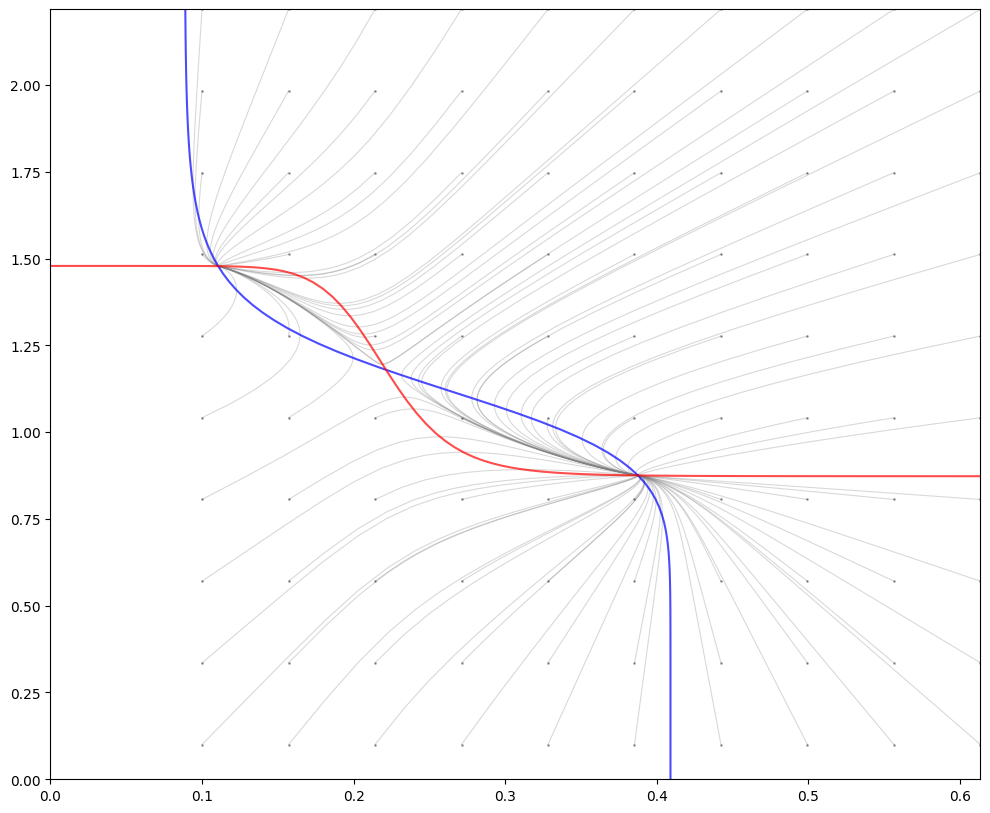

In [ ]:

x0_max = U[1,0] * 1.5
x1_max = U[0,1] * 1.5

x0_starts = np.linspace(0.1, x0_max, 10)
x1_starts = np.linspace(0.1, x1_max, 10)


t_span = (0, 10)


fig = plt.figure(figsize=(12, 10))
gs = GridSpec(1, 1)
ax = fig.add_subplot(gs[0])


X0, X1 = np.meshgrid(x0_starts, x1_starts)
initial_conditions = np.column_stack((X0.ravel(), X1.ravel()))


for ic in initial_conditions:
    sol = solve_ivp(
        lambda t, x: f1(t,x),
        t_span,
        ic,
        method='RK45',
        rtol=1e-6,
        max_step=0.5,
        dense_output=True
    )


    t_dense = np.linspace(0, sol.t[-1], 100)
    y_dense = sol.sol(t_dense)


    points = y_dense.T
    ax.plot(points[:,0], points[:,1], 'gray', alpha=0.3, linewidth=0.8)
    ax.plot(ic[0], ic[1], 'k.', markersize=2, alpha=0.3)


n_grid = 100
xx0 = np.linspace(0, x0_max, n_grid)
xx1 = np.linspace(0, x1_max, n_grid)
XX0, XX1 = np.meshgrid(xx0, xx1)


points = np.stack((XX0, XX1), axis=-1)
UV = np.apply_along_axis(lambda x: f1(0,x), 2, points)


ax.contour(XX0, XX1, UV[:,:,0], levels=[0], colors='blue', alpha=0.7)
ax.contour(XX0, XX1, UV[:,:,1], levels=[0], colors='red', alpha=0.7)

In [ ]:
morse_graph, stg, graded_complex = DSGRN_utils.ConleyMorseGraph(parameter)

None

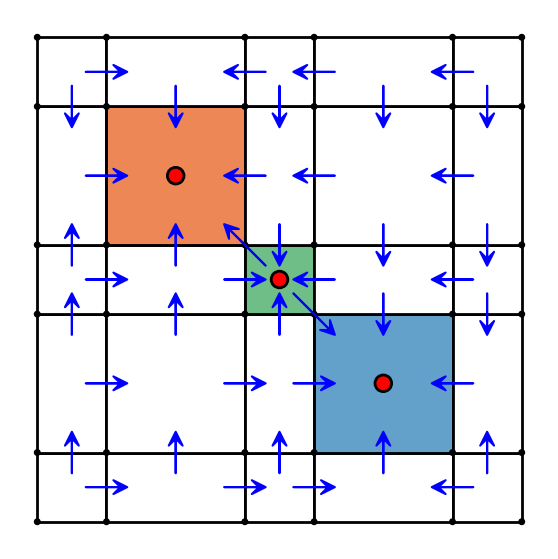

In [ ]:
display(DSGRN_utils.PlotMorseSets(morse_graph, stg, graded_complex))

# Example 2

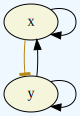

Number of parameter nodes: 1600


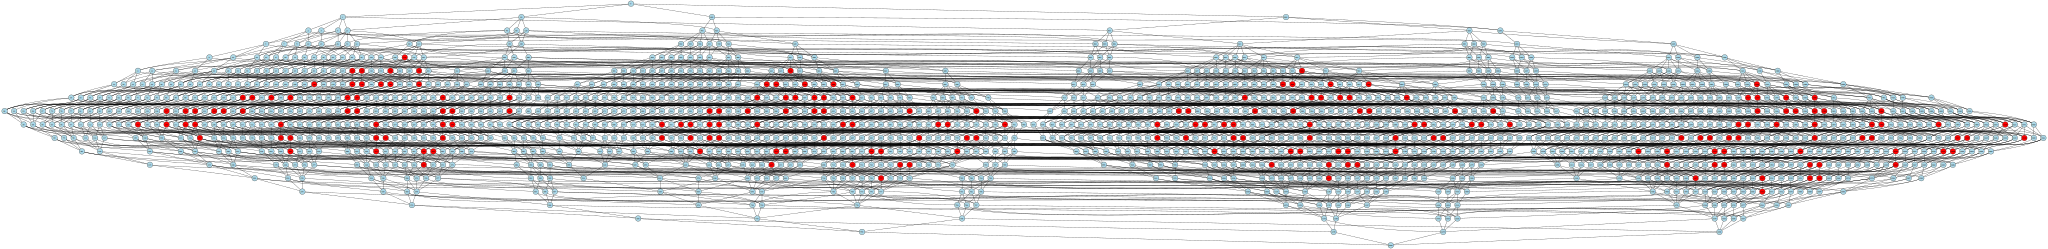

In [ ]:

net_spec = """x : x+y
              y : (~x)y """


network = DSGRN.Network(net_spec)
display(DSGRN.DrawGraph(network))



parameter_graph = DSGRN.ParameterGraph(network)
print('Number of parameter nodes:', parameter_graph.size())
display(DSGRN.draw_parameter_graph(parameter_graph))


sampler = DSGRN.ParameterSampler(network)

In [ ]:

par_index = 712
parameter = parameter_graph.parameter(par_index)
par_sample = sampler.sample(parameter)

None

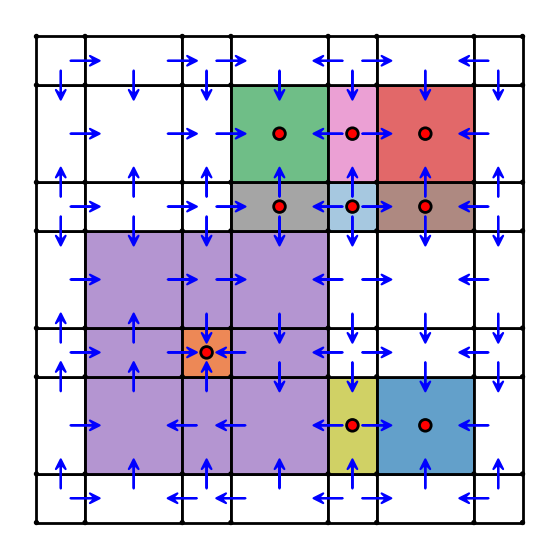

In [ ]:
morse_graph, stg, graded_complex = DSGRN_utils.ConleyMorseGraph(parameter)
display(DSGRN_utils.PlotMorseSets(morse_graph, stg, graded_complex))

In [ ]:

L = np.zeros([network.size(), network.size()])
U = np.zeros([network.size(), network.size()])
T = np.zeros([network.size(), network.size()])

sample_dict = json.loads(par_sample)
for key, value in sample_dict['Parameter'].items():

  par_type = key[0]

  node_names = [name.strip() for name in key[2:-1].split('->')]
  node_indices = [network.index(node) for node in node_names]
  if par_type == 'L':
      L[tuple(node_indices)] = value
  elif par_type == 'U':
      U[tuple(node_indices)] = value
  else:
      T[tuple(node_indices)] = value

In [ ]:
print(T)
parameter.inequalities()

[[0.6998561  0.40893922]
 [1.07432221 1.87056256]]


'{ "inequalities" : "(L[x->x] + L[y->x]) < T[x->y] && T[x->x] < (U[x->x] + L[y->x]) && T[x->y] < (L[x->x] + U[y->x]) < T[x->x] && T[x->x] < (U[x->x] + U[y->x]) && 0 < T[x->y] < T[x->x] && 0 < L[x->x] < U[x->x] && 0 < L[y->x] < U[y->x] && L[x->y] L[y->y] < T[y->x] && T[y->x] < U[x->y] L[y->y] < T[y->y] && T[y->y] < L[x->y] U[y->y] && T[y->y] < U[x->y] U[y->y] && 0 < T[y->x] < T[y->y] && 0 < L[x->y] < U[x->y] && 0 < L[y->y] < U[y->y]", "variables" : "{L[x->x], L[y->x], U[x->x], U[y->x], T[x->y], T[x->x], L[x->y], L[y->y], U[x->y], U[y->y], T[y->x], T[y->y]}"}'

In [ ]:

L = np.array([[0.37524461, 0.53278759],
              [0.51079742, 0.20690897]])
U = np.array([[3.07268995, 1.0738359],
              [1.04642883, 2.12885035]])
T = np.array([[2.0427309, 1.03987091],
              [0.18582819, 0.91593104]])

D = np.zeros([network.size(), network.size()])
D[0,1] = 20
D[1,0] = 15
D[0,0] = 15
D[1,1] = 20

In [ ]:

def ode_function_2(t, x, *params):











  L, U, T, D = params


  hill00 = HillFunction(L[0,0], U[0,0], T[0,0], D[0,0])
  hill01 = HillFunction(U[0,1], L[0,1], T[0,1], D[0,1])

  hill10 = HillFunction(L[1,0], U[1,0], T[1,0], D[1,0])
  hill11 = HillFunction(L[1,1], U[1,1], T[1,1], D[1,1])


  x0, x1 = x


  dx0dt = -x0 + hill00(x0) + hill10(x1)
  dx1dt = -x1 + hill01(x0) * hill11(x1)

  return [dx0dt, dx1dt]

In [ ]:

f2 = lambda t, x: ode_function_2(t, x, L, U, T, D)

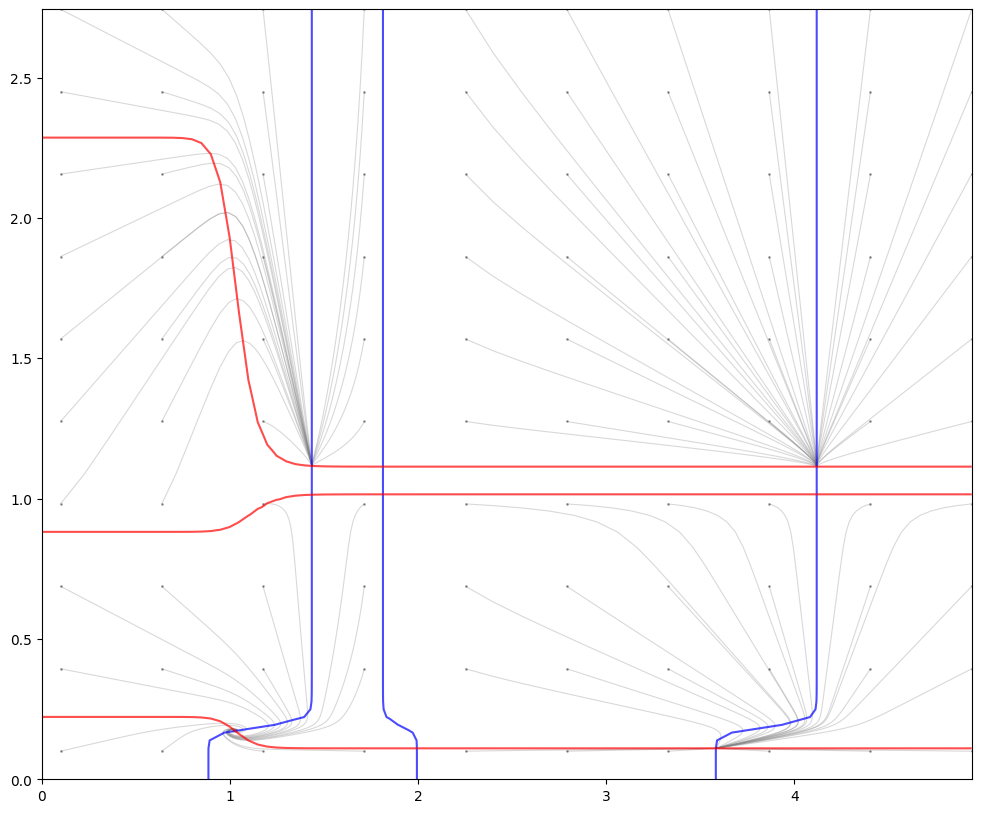

In [ ]:

x0_max = (U[0,0]+U[1,0]) * 1.2
x1_max = (U[0,1]*U[1,1]) * 1.2

x0_starts = np.linspace(0.1, x0_max, 10)
x1_starts = np.linspace(0.1, x1_max, 10)


t_span = (0, 10)


fig = plt.figure(figsize=(12, 10))
gs = GridSpec(1, 1)
ax = fig.add_subplot(gs[0])


X0, X1 = np.meshgrid(x0_starts, x1_starts)
initial_conditions = np.column_stack((X0.ravel(), X1.ravel()))


for ic in initial_conditions:
    sol = solve_ivp(
        lambda t, x: f2(t,x),
        t_span,
        ic,
        method='RK45',
        rtol=1e-6,
        max_step=0.5,
        dense_output=True
    )


    t_dense = np.linspace(0, sol.t[-1], 100)
    y_dense = sol.sol(t_dense)


    points = y_dense.T
    ax.plot(points[:,0], points[:,1], 'gray', alpha=0.3, linewidth=0.8)
    ax.plot(ic[0], ic[1], 'k.', markersize=2, alpha=0.3)


n_grid = 100
xx0 = np.linspace(0, x0_max, n_grid)
xx1 = np.linspace(0, x1_max, n_grid)
XX0, XX1 = np.meshgrid(xx0, xx1)


points = np.stack((XX0, XX1), axis=-1)
UV = np.apply_along_axis(lambda x: f2(0,x), 2, points)


ax.contour(XX0, XX1, UV[:,:,0], levels=[0], colors='blue', alpha=0.7)
ax.contour(XX0, XX1, UV[:,:,1], levels=[0], colors='red', alpha=0.7)

None

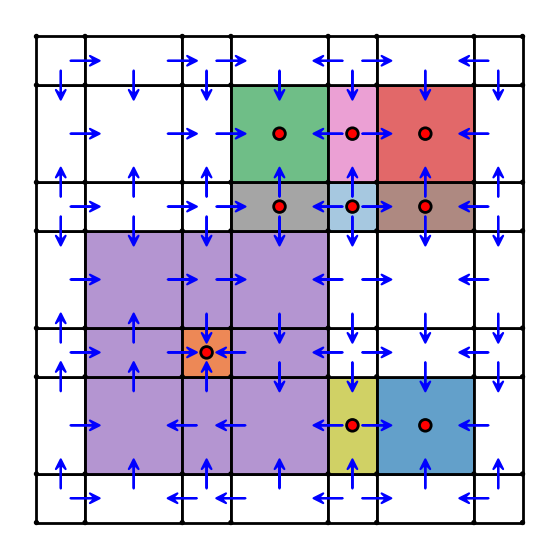

In [ ]:
morse_graph, stg, graded_complex = DSGRN_utils.ConleyMorseGraph(parameter)
display(DSGRN_utils.PlotMorseSets(morse_graph, stg, graded_complex))

# Example 3

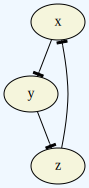

Number of parameter nodes: 27


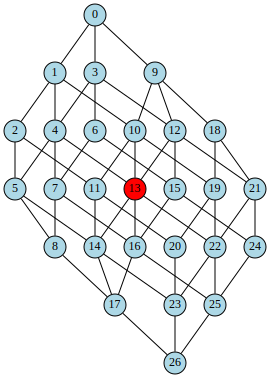

In [ ]:

net_spec = """x : ~z
              y : ~x
              z : ~y  """


network = DSGRN.Network(net_spec)
display(DSGRN.DrawGraph(network))



parameter_graph = DSGRN.ParameterGraph(network)
print('Number of parameter nodes:', parameter_graph.size())
display(DSGRN.draw_parameter_graph(parameter_graph))


sampler = DSGRN.ParameterSampler(network)

In [ ]:

par_index = 13
parameter = parameter_graph.parameter(par_index)


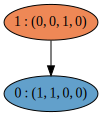

In [ ]:
morse_graph, stg, graded_complex = DSGRN_utils.ConleyMorseGraph(parameter)
DSGRN_utils.PlotMorseGraph(morse_graph)

In [ ]:

L = np.array([[0.0, 0.91322356, 0.0],
              [0.0, 0.0, 0.08856226],
              [0.08186696, 0.0, 0.0]])
U = np.array([[0.0, 1.48087318, 0.0],
              [0.0, 0.0, 0.40910071],
              [2.9182374, 0.0, 0.0]])
T = np.array([[0.0, 0.14056969, 0.0],
              [0.0, 0.0, 0.97137586],
              [0.22193859, 0.0, 0.0]])

D = np.zeros([network.size(), network.size()])
D[0,1] = 15
D[1,2] = 15
D[2,0] = 15

In [ ]:

L = np.array([[0.0, 1.0, 0.0],
              [0.0, 0.0, 1.0],
              [1.0, 0.0, 0.0]])
U = np.array([[0.0, 5.0, 0.0],
              [0.0, 0.0, 5.0],
              [5.0, 0.0, 0.0]])
T = np.array([[0.0, 3.0, 0.0],
              [0.0, 0.0, 3.0],
              [3.0, 0.0, 0.0]])

D = np.zeros([network.size(), network.size()])
D[0,1] = 8
D[1,2] = 8
D[2,0] = 8

In [ ]:

def ode_function_3(t, x, *params):











  L, U, T, D = params


  hill01 = HillFunction(U[0,1], L[0,1], T[0,1], D[0,1])
  hill12 = HillFunction(U[1,2], L[1,2], T[1,2], D[1,2])
  hill20 = HillFunction(U[2,0], L[2,0], T[2,0], D[2,0])

  x0, x1, x2 = x


  dx0dt = -x0 + hill20(x2)
  dx1dt = -x1 + hill01(x0)
  dx2dt = -x2 + hill12(x1)

  return [dx0dt, dx1dt, dx2dt]

In [ ]:

f3 = lambda t, x: ode_function_3(t, x, L, U, T, D)

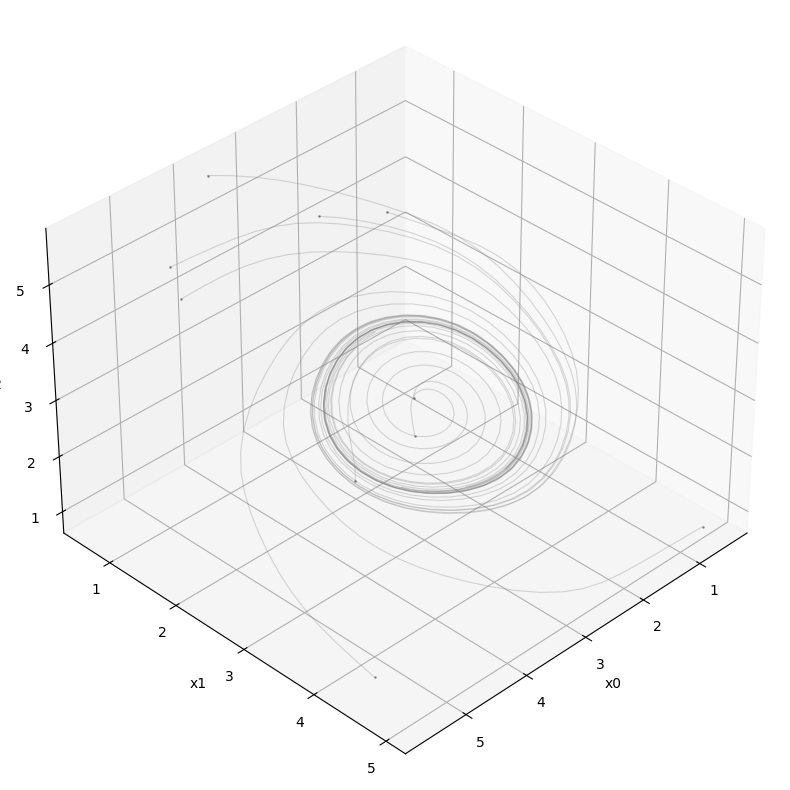

In [ ]:

x0_max = (U[2,0]) * 1.2
x1_max = (U[0,1]) * 1.2
x2_max = (U[1,2]) * 1.2


t_span = (0, 10)


fig = plt.figure(figsize=(12, 10))
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0], projection='3d')


n_points = 10
x0_starts = np.random.uniform(0.1, x0_max, n_points)
x1_starts = np.random.uniform(0.1, x1_max, n_points)
x2_starts = np.random.uniform(0.1, x2_max, n_points)

initial_conditions = np.column_stack((x0_starts, x1_starts, x2_starts))


for ic in initial_conditions:
    sol = solve_ivp(
        lambda t, x: f3(t,x),
        t_span,
        ic,
        method='RK45',
        rtol=1e-6,
        max_step=0.5,
        dense_output=True
    )


    t_dense = np.linspace(0, sol.t[-1], 100)
    x_dense = sol.sol(t_dense)


    points = x_dense.T
    ax.plot(points[:,0], points[:,1], points[:,2], 'gray', alpha=0.3, linewidth=0.8)
    ax.plot(ic[0], ic[1], ic[2], 'k.', markersize=2, alpha=0.3)

ax.view_init(elev=35, azim=45)
ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('x2')

plt.show()

Simulating 10 random trajectories...
Simulating specific trajectory...


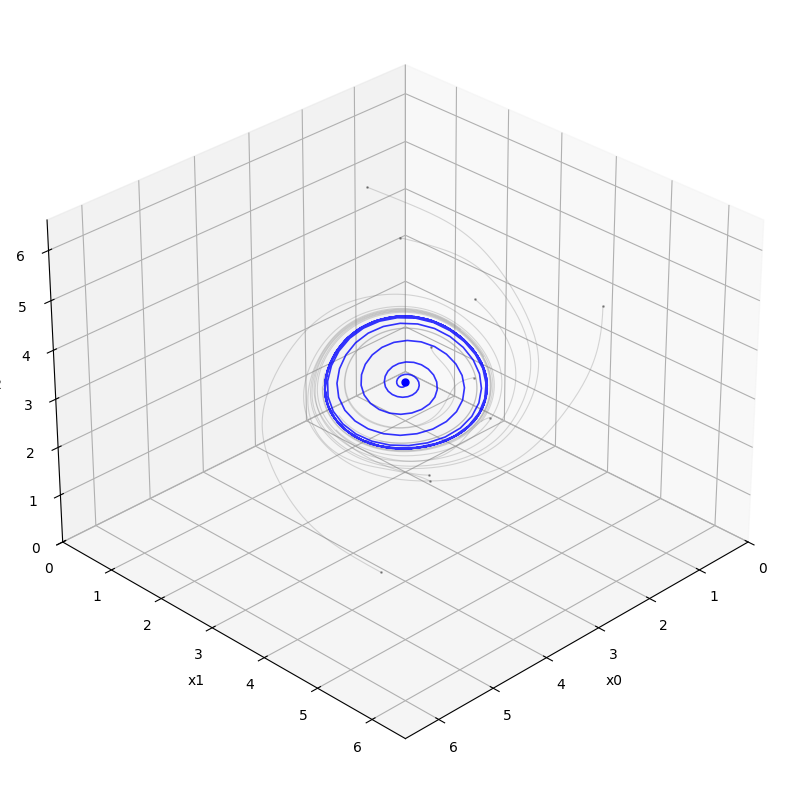

In [ ]:

x0_max = U[2,0] * 1.2
x1_max = U[0,1] * 1.2
x2_max = U[1,2] * 1.2

t_span = (0, 5)
t_span_periodic = (0, 40)

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0], projection='3d')

n_points = 10
x0_starts = np.random.uniform(0.01, x0_max, n_points)
x1_starts = np.random.uniform(0.01, x1_max, n_points)
x2_starts = np.random.uniform(0.01, x2_max, n_points)

initial_conditions = np.column_stack((x0_starts, x1_starts, x2_starts))

print(f"Simulating {n_points} random trajectories...")
for i, ic in enumerate(initial_conditions):
    sol = solve_ivp(
        f3,
        t_span,
        ic,
        method='RK45',
        rtol=1e-6,
        atol=1e-8,
        dense_output=True
    )
    t_dense = np.linspace(sol.t[0], sol.t[-1], 200)
    x_dense = sol.sol(t_dense)

    points = x_dense.T
    ax.plot(points[:,0], points[:,1], points[:,2], 'gray', alpha=0.3, linewidth=0.8)
    ax.plot(ic[0], ic[1], ic[2], 'k.', markersize=2, alpha=0.3)

print("Simulating specific trajectory...")
specific_ic = [0.5,0.5,0.3]

sol_specific = solve_ivp(
    f3,
    t_span_periodic,
    specific_ic,
    method='RK45',
    rtol=1e-8,
    atol=1e-10,
    dense_output=True
)

t_dense_specific = np.linspace(sol_specific.t[0], sol_specific.t[-1], 300)
x_dense_specific = sol_specific.sol(t_dense_specific)
points_specific = x_dense_specific.T

ax.plot(points_specific[:,0], points_specific[:,1], points_specific[:,2],
      'blue', alpha=0.8, linewidth=1.2)
ax.plot(specific_ic[0], specific_ic[1], specific_ic[2],
      'bo', markersize=5)


ax.view_init(elev=30, azim=45)
ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('x2')

ax.set_xlim(0, x0_max * 1.1)
ax.set_ylim(0, x1_max * 1.1)
ax.set_zlim(0, x2_max * 1.1)

plt.show()